# 06 · Machine Learning — 02. Sistema de similitud entre jugadores

Núcleo de la plataforma de scouting. Dado un jugador, encuentra los más **parecidos estadísticamente**
y los presenta con su salario y el **ahorro potencial** respecto al jugador consultado — permitiendo
identificar reemplazos de perfil similar y menor coste.

## Decisiones de diseño

- **Métrica:** distancia **euclídea** sobre los vectores PCA (ya estandarizados con RobustScaler en el
  05_03, por lo que la magnitud está controlada).
- **Espacios separados** por familia de posición (outfielders / porteros), como se construyó en el
  05_03: comparar un portero con un delantero no tiene sentido estadístico.
- **Universo de candidatos:** jugadores **activos en la temporada 25/26**. Se descartan los históricos
  (jugadores cuya última aparición es anterior), ya que el objetivo es scouting actual.
- **Filtro por posición:** los similares se restringen a la misma posición que el jugador consultado.
- **Salario y ahorro potencial:** cada candidato se muestra con su salario real (Capology) y el ahorro
  respecto al jugador de referencia.

## Relación con el modelo de regresión (06_01)

El sistema de similitud es el **núcleo** de la plataforma. El modelo de regresión salarial (06_01)
actúa como **capa complementaria**: puede señalar si un candidato rinde por encima o por debajo de su
ficha, pero la funcionalidad principal —encontrar reemplazos parecidos y más baratos— se sostiene sobre
la similitud y el salario real, datos robustos que no dependen de la precisión del modelo predictivo.

---

## 1. Imports y carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics.pairwise import euclidean_distances

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

ROOT = Path.cwd().parents[1]
SIM_DIR = ROOT / 'data' / 'modeling' / 'similarity'

of = pd.read_csv(SIM_DIR / 'similitud_outfielders.csv')
gk = pd.read_csv(SIM_DIR / 'similitud_keepers.csv')

print(f'Outfielders: {of.shape[0]:,} filas ({of.shape[1]-8} PCs)')
print(f'Porteros:    {gk.shape[0]:,} filas ({gk.shape[1]-8} PCs)')

Outfielders: 13,163 filas (17 PCs)
Porteros:    1,039 filas (13 PCs)


## 2. Preparación: índice de búsqueda y universo de candidatos

Se distinguen dos conjuntos:
- **Universo de consulta:** todos los jugadores-temporada (para poder buscar a cualquiera, incluso en
  temporadas pasadas).
- **Universo de candidatos:** solo jugadores activos en 25/26 (los reemplazos posibles hoy).

In [2]:
def get_pcs(df):
    return [c for c in df.columns if c.startswith('PC')]

PCS_OF = get_pcs(of)
PCS_GK = get_pcs(gk)

# Candidatos: activos en 25/26
of_cand = of[of['season']==2526].reset_index(drop=True)
gk_cand = gk[gk['season']==2526].reset_index(drop=True)

print(f'Candidatos outfielders (25/26): {len(of_cand):,}')
print(f'Candidatos porteros (25/26):    {len(gk_cand):,}')

Candidatos outfielders (25/26): 2,062
Candidatos porteros (25/26):    163


### Nota metodológica: búsqueda de vecinos, no clustering

El sistema recupera, para un jugador dado, los **vecinos más cercanos** en el espacio PCA mediante
distancia euclídea. Conviene precisar dos cosas:

- **No es un modelo k-NN de predicción.** k-NN, como algoritmo de ML, predice una etiqueta o un valor
  a partir de los *k* vecinos. Aquí no se predice nada: se *recuperan* los jugadores más próximos. Es,
  por tanto, una **búsqueda de vecinos más cercanos** (nearest-neighbors search), no una clasificación.

- **No es clustering (k-means).** k-means particiona *todo* el conjunto en grupos predefinidos, pero no
  permite ordenar a los jugadores por cercanía a *uno concreto*. Como el objetivo es una consulta
  personalizada ("¿quién se parece a este jugador?"), la búsqueda de vecinos es el enfoque adecuado.
  El clustering de arquetipos se aborda por separado como análisis complementario (06_03).

El componente de **aprendizaje no supervisado** de este sistema reside en el **PCA** (05_03), que aprende
la estructura latente de las variables de rendimiento; la búsqueda de vecinos opera sobre ese espacio
ya aprendido.

## 3. Función de búsqueda de similares

Calcula la distancia euclídea del jugador de referencia a todos los candidatos activos de su misma
posición, y devuelve los más cercanos con su salario y ahorro potencial.

In [3]:
def buscar_similares(player_id=None, nombre=None, top_n=10, solo_mas_baratos=False,
                     max_edad=None, ligas=None):
    """
    Busca jugadores similares activos en 25/26.
    - Identifica al jugador por player_id (preferido) o por nombre (puede ser ambiguo).
    - Filtra a la misma posición y, opcionalmente, por salario inferior, edad y liga.
    """
    # Determinar en qué espacio está (outfielder o portero)
    for df_full, df_cand, pcs, etiqueta in [
        (of, of_cand, PCS_OF, 'outfielder'),
        (gk, gk_cand, PCS_GK, 'portero')
    ]:
        if player_id is not None:
            m = df_full[df_full['player_id']==player_id]
        else:
            m = df_full[df_full['player'].str.contains(nombre, case=False, na=False, regex=False)]
        if len(m) > 0:
            break
    if len(m) == 0:
        print(f'❌ Jugador no encontrado'); return None

    # Tomar la fila más reciente del jugador de referencia
    ref = m.sort_values('season').iloc[-1]

    # Distancias a los candidatos de la misma posición
    cand = df_cand[(df_cand['position']==ref['position']) &
                   (df_cand['player_id']!=ref['player_id'])].copy()
    vec_ref = ref[pcs].values.reshape(1, -1).astype(float)
    cand['distancia'] = euclidean_distances(vec_ref, cand[pcs].values.astype(float)).flatten()

    sal_ref = ref['gross_annual_eur']
    cand['ahorro_M'] = (sal_ref - cand['gross_annual_eur']) / 1e6

    # Filtros opcionales
    if solo_mas_baratos and pd.notna(sal_ref):
        cand = cand[cand['gross_annual_eur'] < sal_ref]
    if max_edad is not None:
        cand = cand[cand['age'] <= max_edad]
    if ligas is not None:
        cand = cand[cand['country'].isin(ligas)]

    cand = cand.sort_values('distancia').head(top_n)

    print(f"🎯 Similares a {ref['player']} ({ref['position']}, {ref['team']}, "
          f"temporada {ref['season']}) — salario {sal_ref/1e6:.1f}M€\n")
    out = cand[['player','team','country','age','gross_annual_eur','distancia','ahorro_M']].copy()
    out['salario_M'] = (out['gross_annual_eur']/1e6).round(1)
    out['distancia'] = out['distancia'].round(2)
    out['ahorro_M'] = out['ahorro_M'].round(1)
    return out[['player','team','country','age','salario_M','distancia','ahorro_M']]

## 4. Ejemplos de uso

### 4.1 Reemplazos para un delantero de élite

In [4]:
# Robert Lewandowski (delantero, FC Barcelona) — player_id 41789
display(buscar_similares(player_id=41789, top_n=10))

🎯 Similares a Robert Lewandowski (F, FC Barcelona, temporada 2526) — salario 20.8M€



,player,team,country,age,salario_M,distancia,ahorro_M
427,Odsonne Édouard,RC Lens,france,28.0,3.1,3.97,17.7
851,Nicolas Jackson,FC Bayern München,germany,24.0,7.6,4.99,13.3
1791,Victor Osimhen,Galatasaray,turkey,27.0,18.8,5.85,2.1
805,Serhou Guirassy,Borussia Dortmund,germany,29.0,9.4,5.91,11.4
283,Callum Wilson,West Ham United,england,33.0,3.0,6.00,17.8
503,Ahmadou Bamba Dieng,Lorient,france,25.0,0.9,6.01,19.9
1029,Lautaro Martínez,Inter,italy,28.0,16.7,6.08,4.2
214,Jean Philippe Mateta,Crystal Palace,england,28.0,3.6,6.18,17.2
506,Ansu Fati,AS Monaco,france,23.0,2.6,6.34,18.2
454,Joaquin Panichelli,RC Strasbourg,france,23.0,1.6,6.59,19.2


### 4.2 Reemplazos para un centrocampista organizador

In [5]:
# Pedri (mediocentro, FC Barcelona) — player_id 992587
# (se usa player_id para evitar ambigüedad: 'Pedri' por nombre coincidiría también con 'Pedrinho')
display(buscar_similares(player_id=992587, top_n=10))

🎯 Similares a Pedri (M, FC Barcelona, temporada 2526) — salario 12.5M€



,player,team,country,age,salario_M,distancia,ahorro_M
1002,Luka Modrić,Milan,italy,40.0,6.5,5.13,6.0
1014,Nicolo Barella,Inter,italy,28.0,12.0,5.18,0.5
1001,Manuel Locatelli,Juventus,italy,28.0,6.1,5.39,6.4
357,Vitinha,Paris Saint-Germain,france,25.0,11.8,5.51,0.7
1010,Nicolò Fagioli,Fiorentina,italy,24.0,3.3,5.81,9.2
681,Joshua Kimmich,FC Bayern München,germany,30.0,20.0,5.88,-7.5
1392,Aleix Febas,Elche,spain,30.0,1.2,6.28,11.2
1,Bruno Guimarães,Newcastle United,england,28.0,9.6,6.35,2.9
1384,Frenkie de Jong,FC Barcelona,spain,28.0,19.0,6.42,-6.5
1018,Piotr Zielinski,Inter,italy,31.0,8.3,6.50,4.2


### 4.3 Reemplazos más baratos para un extremo (filtro de salario inferior)

In [6]:
# Vinicius Júnior (extremo, Real Madrid) — player_id 868812
display(buscar_similares(player_id=868812, top_n=10, solo_mas_baratos=True))

🎯 Similares a Vinicius Júnior (F, Real Madrid, temporada 2526) — salario 25.0M€



,player,team,country,age,salario_M,distancia,ahorro_M
1005,Kenan Yıldız,Juventus,italy,20.0,3.0,4.70,22.0
1403,Dani Olmo,FC Barcelona,spain,27.0,12.5,4.99,12.5
371,Khvicha Kvaratskhelia,Paris Saint-Germain,france,24.0,16.4,5.17,8.6
1410,Fermín López,FC Barcelona,spain,22.0,7.3,5.32,17.7
387,Matías Fernández,Lille,france,21.0,1.2,5.36,23.8
20,Bukayo Saka,Arsenal,england,24.0,11.7,5.59,13.3
679,Yan Diomande,RB Leipzig,germany,19.0,0.8,5.88,24.2
1388,Abdessamad Ezzalzouli,Real Betis,spain,24.0,1.5,6.04,23.5
362,Bradley Barcola,Paris Saint-Germain,france,23.0,7.3,6.12,17.7
687,Luis Díaz,FC Bayern München,germany,29.0,14.0,6.14,11.0


### 4.4 Reemplazo joven y barato (filtros combinados: edad ≤ 23 y salario inferior)

In [7]:
# Vinicius Júnior, filtrando reemplazos jóvenes (≤23) y más baratos
display(buscar_similares(player_id=868812, top_n=10, solo_mas_baratos=True, max_edad=23))

🎯 Similares a Vinicius Júnior (F, Real Madrid, temporada 2526) — salario 25.0M€



,player,team,country,age,salario_M,distancia,ahorro_M
1005,Kenan Yıldız,Juventus,italy,20.0,3.0,4.70,22.0
1410,Fermín López,FC Barcelona,spain,22.0,7.3,5.32,17.7
387,Matías Fernández,Lille,france,21.0,1.2,5.36,23.8
679,Yan Diomande,RB Leipzig,germany,19.0,0.8,5.88,24.2
362,Bradley Barcola,Paris Saint-Germain,france,23.0,7.3,6.12,17.7
389,Pablo Pagis,Lorient,france,23.0,0.7,6.77,24.3
708,Can Uzun,Eintracht Frankfurt,germany,20.0,1.3,6.86,23.7
1006,Nico Paz,Como,italy,21.0,0.9,6.91,24.1
1466,Nico Williams,Athletic Club,spain,23.0,16.7,6.99,8.3
1389,Jude Bellingham,Real Madrid,spain,22.0,20.8,7.18,4.2


### 4.5 Reemplazos para un portero

In [8]:
# Jan Oblak (portero, Atlético de Madrid) — player_id 69768
display(buscar_similares(player_id=69768, top_n=10))

🎯 Similares a Jan Oblak (K, Atlético Madrid, temporada 2526) — salario 20.8M€



,player,team,country,age,salario_M,distancia,ahorro_M
84,Mile Svilar,Roma,italy,26.0,4.4,1.97,16.5
148,Ederson,Fenerbahçe,turkey,32.0,13.8,2.16,7.1
129,Thibaut Courtois,Real Madrid,spain,33.0,15.0,2.24,5.8
7,Senne Lammens,Manchester United,england,23.0,3.6,2.30,17.2
0,Bart Verbruggen,Brighton & Hove Albion,england,23.0,2.1,2.34,18.7
29,Berke Özer,Lille,france,25.0,1.6,2.37,19.2
149,Ersin Destanoğlu,Beşiktaş JK,turkey,25.0,0.9,2.40,20.0
124,Augusto Batalla,Rayo Vallecano,spain,29.0,2.1,2.47,18.8
8,Karl Darlow,Leeds United,england,35.0,1.8,2.48,19.0
150,Andreas Gianniotis,Kasımpaşa,turkey,33.0,0.4,2.50,20.4


## 5. Validación cualitativa

Para validar que el sistema captura el estilo de juego (y no solo ruido), se comprueba que los
similares de jugadores conocidos sean coherentes futbolísticamente.

In [9]:
# Se usan player_id para evitar ambigüedad de nombres (p.ej. 'Rodri' coincide con 23 jugadores)
casos = {
    'Rodri (M, Man City)':      827606,
    'Luka Modrić (M, Milan)':   15466,
    'Erling Haaland (F, City)': 839956,
    'William Saliba (D, Arsenal)': 941168,
    'Theo Hernández (D, Milan)':   788027,
}
for etiqueta, pid in casos.items():
    print(f'### {etiqueta}')
    r = buscar_similares(player_id=pid, top_n=5)
    if r is not None:
        print(r.to_string(index=False))
    print()

### Rodri (M, Man City)
🎯 Similares a Rodri (M, Manchester City, temporada 2526) — salario 13.3M€

               player                   team country  age  salario_M  distancia  ahorro_M
     Manuel Locatelli               Juventus   italy 28.0        6.1       4.81       7.1
    Eduardo Camavinga            Real Madrid   spain 23.0       12.5       5.49       0.8
Pierre-Emile Højbjerg Olympique de Marseille  france 30.0        5.4       5.58       7.8
    Exequiel Palacios    Bayer 04 Leverkusen germany 27.0        7.6       5.65       5.7
         Granit Xhaka             Sunderland england 33.0        6.6       5.81       6.6

### Luka Modrić (M, Milan)
🎯 Similares a Luka Modrić (M, Milan, temporada 2526) — salario 6.5M€

          player          team country  age  salario_M  distancia  ahorro_M
  Nicolò Fagioli    Fiorentina   italy 24.0        3.3       3.74       3.2
Manuel Locatelli      Juventus   italy 28.0        6.1       3.79       0.4
  Nicolo Barella         Inter   it

## 6. Visualización: mapa de similitud (2D)

Proyección de los dos primeros componentes principales, situando un jugador de referencia y sus
similares para ilustrar visualmente la cercanía en el espacio de estilo.

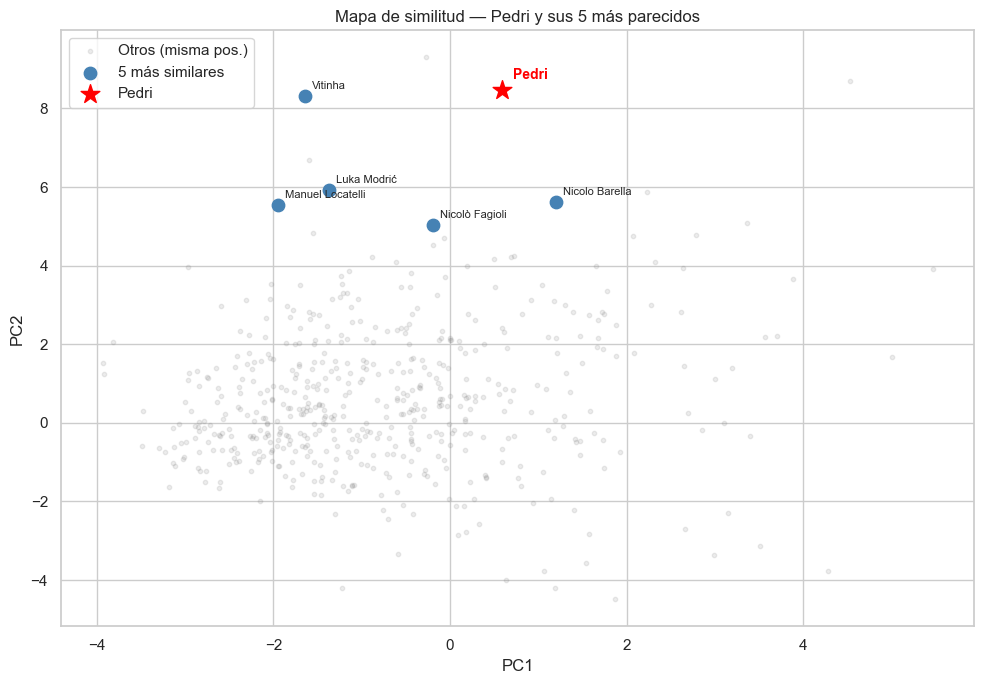

In [10]:
# Pedri (player_id 992587) como referencia del mapa
ref = of[of['player_id']==992587].sort_values('season').iloc[-1]
cand = of_cand[(of_cand['position']==ref['position']) & (of_cand['player_id']!=ref['player_id'])].copy()
cand['dist'] = euclidean_distances(ref[PCS_OF].values.reshape(1,-1).astype(float),
                                   cand[PCS_OF].values.astype(float)).flatten()
top5 = cand.nsmallest(5, 'dist')

fig, ax = plt.subplots(figsize=(10, 7))
# nube de fondo (misma posición)
fondo = of_cand[of_cand['position']==ref['position']]
ax.scatter(fondo['PC1'], fondo['PC2'], s=10, alpha=0.15, color='gray', label='Otros (misma pos.)')
# similares
ax.scatter(top5['PC1'], top5['PC2'], s=80, color='steelblue', label='5 más similares', zorder=3)
for _, r in top5.iterrows():
    ax.annotate(r['player'], (r['PC1'], r['PC2']), fontsize=8, xytext=(5,5), textcoords='offset points')
# referencia
ax.scatter(ref['PC1'], ref['PC2'], s=200, color='red', marker='*', label=ref['player'], zorder=4)
ax.annotate(ref['player'], (ref['PC1'], ref['PC2']), fontsize=10, fontweight='bold',
            xytext=(8,8), textcoords='offset points', color='red')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'Mapa de similitud — {ref["player"]} y sus 5 más parecidos')
ax.legend()
plt.tight_layout(); plt.show()

## 7. Conclusiones

### Sistema construido
Sistema de similitud basado en distancia euclídea sobre los vectores PCA (05_03), separado por familia
de posición. Dado un jugador, devuelve candidatos activos en 25/26 con perfil estadístico parecido, su
salario real y el ahorro potencial, con filtros opcionales (salario inferior, edad, liga).

### Validación
La inspección cualitativa confirma que los similares son coherentes futbolísticamente: los
centrocampistas organizadores se emparejan entre sí (Pedri ↔ Modrić, Barella, Vitinha), los delanteros
centro killers también (Lewandowski ↔ Osimhen, Lautaro, Guirassy), etc.

### Valor para la plataforma
Esta es la funcionalidad central del producto final: una herramienta de scouting que, partiendo de un
jugador, propone alternativas de perfil similar y menor coste. Se apoya en datos robustos (vectores de
estilo validados y salario real), sin depender de la precisión del modelo predictivo de salario.

### Integración con la regresión (06_01)
En la plataforma, el residuo del modelo de regresión puede mostrarse como información complementaria
("este candidato rinde por encima de su ficha"), enriqueciendo la recomendación sin ser el criterio
principal.

### Próximos pasos
- Despliegue en Streamlit: selección de jugador (por `player_id` para evitar ambigüedad de nombres),
  filtros interactivos y visualización del mapa de similitud.